# EDA (P0 выгрузки лактаций)

Демо-EDA для структуры P0. Замените `data/raw/demo_lactations_p0.csv` на выгрузку клиента и перезапустите.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/content/demo_lactations_p0.csv"
today = pd.Timestamp("2025-12-20")

df = pd.read_csv(DATA_PATH, parse_dates=["calving_date"])
df.head()

,farm,animal_id,parity,calving_date,milk_305_kg,fat_pct,protein_pct,scc
0,farm_4,A000001,1,2022-09-15,7920.006236,3.956617,3.272322,NaN
1,farm_4,A000001,2,2023-10-11,8246.369099,NaN,NaN,NaN
2,farm_4,A000001,3,2024-10-26,9402.884454,3.652278,NaN,NaN
3,farm_4,A000001,4,2025-10-17,10756.199481,3.473099,2.870680,NaN
4,farm_4,A000001,5,2026-11-02,10826.438628,3.607660,3.226746,NaN


In [2]:
# Обзор датасета
summary = {
    "rows": len(df),
    "unique_animals": df["animal_id"].nunique(),
    "unique_farms": df["farm"].nunique(),
    "calving_date_min": df["calving_date"].min(),
    "calving_date_max": df["calving_date"].max(),
}
summary

{'rows': 24017,
 'unique_animals': 6000,
 'unique_farms': 8,
 'calving_date_min': Timestamp('2018-01-01 00:00:00'),
 'calving_date_max': Timestamp('2035-12-19 00:00:00')}

In [3]:
# Проверки качества
key_cols = ["farm","animal_id","parity","calving_date"]

dup_count = df.duplicated(subset=key_cols).sum()
invalid_milk = (df["milk_305_kg"] <= 0).sum()
invalid_parity = (~df["parity"].between(1, 12)).sum()
future_dates = (df["calving_date"] > today).sum()

dup_count, invalid_milk, invalid_parity, future_dates

(np.int64(47), np.int64(23), np.int64(23), np.int64(4771))

In [4]:
# Пропуски
missing = df.isna().mean().sort_values(ascending=False)
missing

,0
scc,0.273140
protein_pct,0.222134
fat_pct,0.178665
farm,0.000000
calving_date,0.000000
parity,0.000000
animal_id,0.000000
milk_305_kg,0.000000


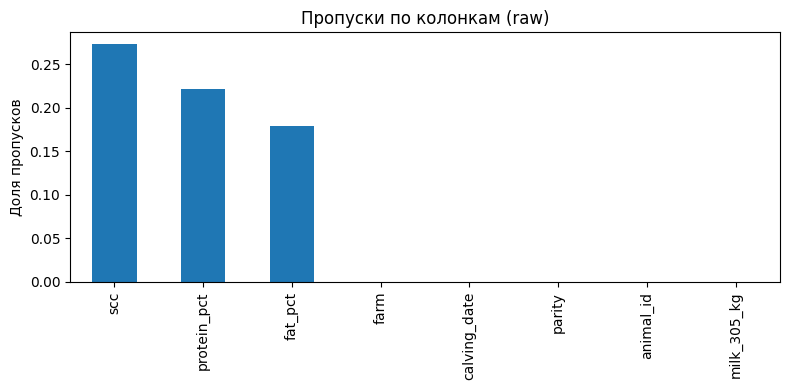

In [5]:
plt.figure(figsize=(8,4))
missing.plot(kind="bar")
plt.ylabel("Доля пропусков")
plt.title("Пропуски по колонкам (raw)")
plt.tight_layout()
plt.show()

In [6]:
# Базовая очистка для EDA-графиков (не финальная)
df_clean = df.copy()
df_clean = df_clean[df_clean["milk_305_kg"] > 0]
df_clean = df_clean[df_clean["parity"].between(1, 12)]
df_clean = df_clean[df_clean["calving_date"] <= today]
len(df_clean)

19208

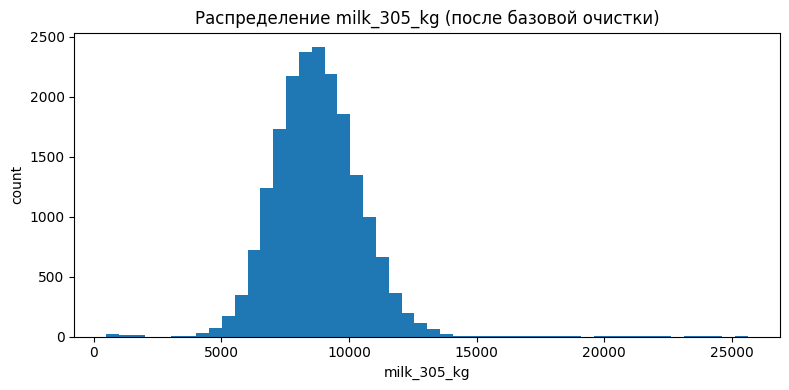

In [7]:
plt.figure(figsize=(8,4))
plt.hist(df_clean["milk_305_kg"], bins=50)
plt.xlabel("milk_305_kg")
plt.ylabel("count")
plt.title("Распределение milk_305_kg (после базовой очистки)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1216223069.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=parities, showfliers=False)


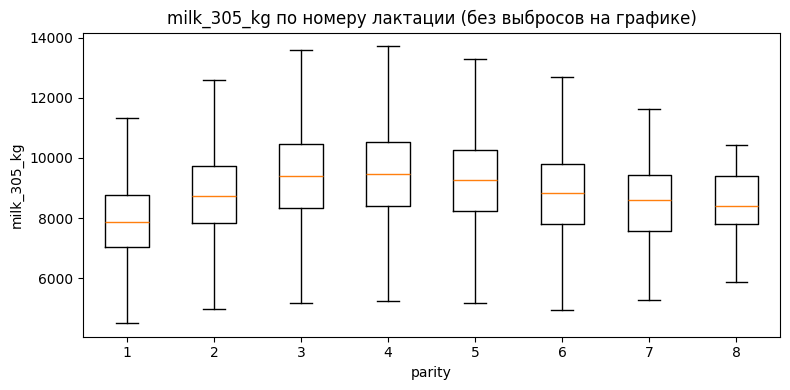

In [8]:
# Boxplot по parity
parities = sorted(df_clean["parity"].unique())
data = [df_clean.loc[df_clean["parity"]==p, "milk_305_kg"].values for p in parities]

plt.figure(figsize=(8,4))
plt.boxplot(data, labels=parities, showfliers=False)
plt.xlabel("parity")
plt.ylabel("milk_305_kg")
plt.title("milk_305_kg по номеру лактации (без выбросов на графике)")
plt.tight_layout()
plt.show()

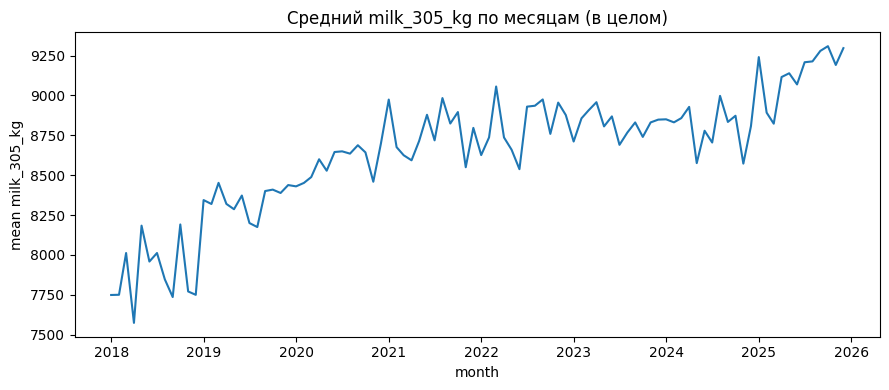

In [9]:
# Тренд по времени (в целом)
tmp = df_clean.copy()
tmp["month"] = tmp["calving_date"].dt.to_period("M").dt.to_timestamp()
overall = tmp.groupby("month")["milk_305_kg"].mean()

plt.figure(figsize=(9,4))
plt.plot(overall.index, overall.values)
plt.xlabel("month")
plt.ylabel("mean milk_305_kg")
plt.title("Средний milk_305_kg по месяцам (в целом)")
plt.tight_layout()
plt.show()

## Выводы
- Для MVP обязателен слой QC/валидаторов (даты, диапазоны, дубли).
- `parity` и `farm/site` критичны как признаки.
- Нужна time-based валидация из-за сезонности/дрейфа.
- Показатели качества молока часто неполные → не делаем их обязательными для P0.